# Imports

In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score

from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.svm import SVC

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import classification_report


# Charger, observer et comprendre le dataset

In [19]:
df = pd.read_csv('credit.csv')

y = df['Loan_Status']
X = df.drop(columns=['Loan_Status','Loan_ID'])
X_columns = X.columns
print(X_columns)

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')


# Transformer les données catégorielles en données numériques

In [20]:
X_columns = X.columns
print(X_columns)
encoder = OrdinalEncoder()
print(X)
X = encoder.fit_transform(X)
print(X)

encoder = LabelEncoder()
y = encoder.fit_transform(y)

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')
     Gender Married Dependents     Education Self_Employed  ApplicantIncome  \
0      Male      No          0      Graduate            No             5849   
1      Male     Yes          1      Graduate            No             4583   
2      Male     Yes          0      Graduate           Yes             3000   
3      Male     Yes          0  Not Graduate            No             2583   
4      Male      No          0      Graduate            No             6000   
..      ...     ...        ...           ...           ...              ...   
609  Female      No          0      Graduate            No             2900   
610    Male     Yes         3+      Graduate            No             4106   
611    Male     Yes          1      Graduate            No             

# Afficher et traiter les données manquantes
Pour traiter les données manquantes, regarder `SimpleImputer` ou `KNNImputer`

In [21]:
imputer = KNNImputer(n_neighbors=5)

X = imputer.fit_transform(X)


# Standardiser les données

In [22]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

print(X)


[[ 0.4814512  -1.3709104  -0.76438894 ...  0.30760399  0.45080053
   1.22329839]
 [ 0.4814512   0.73238542  0.23038598 ...  0.30760399  0.45080053
  -1.31851281]
 [ 0.4814512   0.73238542 -0.76438894 ...  0.30760399  0.45080053
   1.22329839]
 ...
 [ 0.4814512   0.73238542  0.23038598 ...  0.30760399  0.45080053
   1.22329839]
 [ 0.4814512   0.73238542  1.22516091 ...  0.30760399  0.45080053
   1.22329839]
 [-2.11162808 -1.3709104  -0.76438894 ...  0.30760399 -2.39100157
  -0.04760721]]


# Séparer le dataset en train et test

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Régression logistique
Entrainer une régression logistique avec les hyper-paramètres par défaut

In [24]:
regr_log = LogisticRegression()

regr_log.fit(X_train, y_train)

LogisticRegression()

In [25]:
print(f'Train acc: {regr_log.score(X_train, y_train)}')
print(f'Test acc: {regr_log.score(X_test, y_test)}')

Train acc: 0.7983706720977597
Test acc: 0.8292682926829268


# KNN
Entrainer un KNN avec les hyper-paramètres par défaut
Avec `GridSearchCV` ou `RandomizedSearchCV`, optimiser les hyper-paramètres. Utiliser une validation croisée de 5 splits. Vous explorerez les paramètres suivants:
- k : 3, 5, 7, 9, 11,
- poids : uniform, distance,
- distances : euclidean, manhattan, minkowski

In [26]:
xgboost = KNeighborsClassifier()
xgboost.fit(X_train, y_train)

y_pred_train = xgboost.predict(X_train)
y_pred_test = xgboost.predict(X_test)

print(f'Train acc : {accuracy_score(y_train, y_pred_train)}')
print(f'Test acc : {accuracy_score(y_test, y_pred_test)}')

Train acc : 0.8085539714867617
Test acc : 0.7804878048780488


In [27]:
param_grid_knn = {
    'n_neighbors': [3,5,7,9,11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

In [28]:
grid_search = GridSearchCV(estimator=xgboost, scoring='accuracy', param_grid=param_grid_knn, cv=5, n_jobs=-1) #cv pour cross validation, verbose pour montrer les étapes qui sont effectuées

In [29]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': [3, 5, 7, 9, 11],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [30]:
grid_search.best_params_

{'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}

In [31]:
xgboost_best = grid_search.best_estimator_

y_pred_train = xgboost_best.predict(X_train)
y_pred_test = xgboost_best.predict(X_test)

print(f'Train acc : {accuracy_score(y_train, y_pred_train)}')
print(f'Test acc : {accuracy_score(y_test, y_pred_test)}')

Train acc : 1.0
Test acc : 0.8048780487804879


# SVM
Entrainer un SVM avec les hyper-paramètres par défaut
Avec `GridSearchCV` ou `RandomizedSearchCV`, optimiser les hyper-paramètres. Utiliser une validation croisée de 5 splits. Vous explorerez les paramètres suivants:
- C : 0.01, 0.1, 1, 10, 100,
- noyau : linear, poly, rbf, sigmoid,
- gamma : scale, auto, 0.001, 0.01, 0.1, 1,
- degrée du polynome : 2, 3, 4, 5

In [32]:
clf = SVC()

clf.fit(X_train, y_train)

print(f'Train acc: {clf.score(X_train, y_train)}')
print(f'Test acc: {clf.score(X_test, y_test)}')



Train acc: 0.8167006109979633
Test acc: 0.8292682926829268


In [33]:
param_grid_svm = {
    'C': [00.1, 0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'degree': [2,3,4,5]
}

In [34]:
grid_search = GridSearchCV(estimator=clf, scoring='accuracy', param_grid=param_grid_svm, cv=5, n_jobs=-1) #cv pour cross validation, verbose pour montrer les étapes qui sont effectuées

In [35]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 0.1, 1, 10, 100], 'degree': [2, 3, 4, 5],
                         'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
                         'kernel': ['linear', 'rbf', 'poly', 'sigmoid']},
             scoring='accuracy')

In [36]:
grid_search.best_estimator_

SVC(C=1, degree=2)

In [37]:
clf_best = grid_search.best_estimator_

y_pred_train = clf_best.predict(X_train)
y_pred_test = clf_best.predict(X_test)

print(f'Train acc : {accuracy_score(y_train, y_pred_train)}')
print(f'Test acc : {accuracy_score(y_test, y_pred_test)}')

Train acc : 0.8167006109979633
Test acc : 0.8292682926829268


# DecisionTree
Entrainer un arbre de décision avec les hyper-paramètres par défaut
Avec `GridSearchCV` ou `RandomizedSearchCV`, optimiser les hyper-paramètres. Utiliser une validation croisée de 5 splits. Vous explorerez les hyper-paramètres suivants:
- critère : gini, entropy,
- profondeur maximale : None, 10, 20, 30, 40, 50,
- nombre minimum d'exemples par split : 2, 5, 10, 20,
- nombre minimum d'exemples par feuille : 1, 2, 4, 6,
- nombre de features maximum : None, sqrt, log2

In [38]:
xgboost = DecisionTreeClassifier()

xgboost.fit(X_train, y_train)

print(f'Train acc: {xgboost.score(X_train, y_train)}')
print(f'Test acc: {xgboost.score(X_test, y_test)}')

Train acc: 1.0
Test acc: 0.6910569105691057


In [39]:
param_grid_xgboost = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2,5,10,20],
    'min_samples_leaf': [1,2,4,6],
    'max_features': [None, 'sqrt', 'log2']
}

In [40]:
grid_search = GridSearchCV(estimator=xgboost, scoring='accuracy', param_grid=param_grid_xgboost, cv=5, n_jobs=-1) #cv pour cross validation, verbose pour montrer les étapes qui sont effectuées

In [41]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 10, 20, 30, 40, 50],
                         'max_features': [None, 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4, 6],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='accuracy')

In [42]:
grid_search.best_estimator_

DecisionTreeClassifier(criterion='entropy', max_depth=10, max_features='log2',
                       min_samples_split=20)

In [43]:
decision_tree_best = grid_search.best_estimator_

y_pred_train = decision_tree_best.predict(X_train)
y_pred_test = decision_tree_best.predict(X_test)

print(f'Train acc : {accuracy_score(y_train, y_pred_train)}')
print(f'Test acc : {accuracy_score(y_test, y_pred_test)}')

Train acc : 0.8553971486761711
Test acc : 0.8048780487804879


# RandomForest
Entrainer une forêt aléatoire avec les paramètres par défaut
Avec `GridSearchCV` ou `RandomizedSearchCV`, optimiser les hyper-paramètres. Utiliser une validation croisée de 5 splits. Vous explorerez les hyper-paramètres suivants:
- nombre d'arbres : 50, 100, 200, 300,
- critère : gini, entropy,
- profondeur maximale : None, 10, 20, 30, 40, 50,
- nombre minimum d'exemples par split : 2, 5, 10, 20,
- nombre minimum d'exemples par feuille : 1, 2, 4, 6,
- nombre de features maximum : None, sqrt, log2,
- remise des exemples : vrai, faux

In [44]:
xgboost = RandomForestClassifier()

xgboost.fit(X_train, y_train)

print(f'Train acc: {xgboost.score(X_train, y_train)}')
print(f'Test acc: {xgboost.score(X_test, y_test)}')

Train acc: 1.0
Test acc: 0.8048780487804879


In [45]:
param_grid_xgboost = {
    'n_estimators': [20,100,200,300],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2,5,10,20],
    'min_samples_leaf': [1,2,4,6],
    'max_features': [None, 'sqrt', 'log2'],
    'bootstrap': [True, False]
}

In [46]:
randomized_search = RandomizedSearchCV(estimator=xgboost, scoring='accuracy', param_distributions=param_grid_xgboost, cv=5, n_jobs=-1, n_iter=1000) # relancer avec + de n_iter

In [47]:
randomized_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=1000,
                   n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'criterion': ['gini', 'entropy'],
                                        'max_depth': [None, 10, 20, 30, 40, 50],
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4, 6],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'n_estimators': [20, 100, 200, 300]},
                   scoring='accuracy')

In [48]:
randomized_search.best_estimator_

RandomForestClassifier(criterion='entropy', max_depth=40, min_samples_split=20,
                       n_estimators=20)

In [49]:
random_forest_best = randomized_search.best_estimator_

y_pred_train = random_forest_best.predict(X_train)
y_pred_test = random_forest_best.predict(X_test)

print(f'Train acc : {accuracy_score(y_train, y_pred_train)}')
print(f'Test acc : {accuracy_score(y_test, y_pred_test)}')

Train acc : 0.8411405295315683
Test acc : 0.8292682926829268


# Rapporter et analyser les résultats obtenir. Choisir le meilleur modèle

| algo | hyperparams | train | test |
|:----:|:-----------:|:-----:|:----:|
|Regression logistique|default|0.80|0.82|
|KNN|default|0.81|0.80|
|KNN|metric: euclidean, n_neighbors: 11, weights: uniform|0.81|0.82|
|SVM|default|0.80|0.82|
|SVM|C: 1, gamma: scale, kernel: rbf|0.82|0.82|
|Decision Tree|default|1.00|0.65|
|Decision Tree|max_features='sqrt', min_samples_leaf=4, min_samples_split=20|0.82|0.72|
|Random Forest|default|1.00|0.78|
|Random Forest|max_depth=50, min_samples_leaf=2, min_samples_split=20, n_estimators=20|0.84|0.78|

## Meilleur modèle
Le meilleur modèle est l'algorithme SVM avec les hyper-paramètres suivant:
* C: 1
* gamma: scale
* kernel: rbf




# Analyser le meilleur modèle
En utilisant `classification_report`, afficher différentes métriques en train et en test du modèle choisit. Afficher la matrice de confusion en train et en test de ce même modèle. Qu'en concluez-vous sur la qualité de ce modèle?

In [50]:
clf = SVC(C=1, gamma='scale', kernel='rbf')
clf.fit(X_train, y_train)
y_pred_train = clf_best.predict(X_train)
y_pred_test = clf_best.predict(X_test)

y_true = y_train
y_pred = y_pred_train
target_names = ['Y', 'N']

print(classification_report(y_true, y_pred, target_names=target_names))


              precision    recall  f1-score   support

           Y       0.95      0.46      0.62       159
           N       0.79      0.99      0.88       332

    accuracy                           0.82       491
   macro avg       0.87      0.72      0.75       491
weighted avg       0.84      0.82      0.79       491



# Exercice 1 - Feature Selection

### Matrice de corrélation

In [51]:
import seaborn as sns

In [52]:
credit_df = pd.DataFrame(data=X_train, columns=X_columns)

<Axes: >

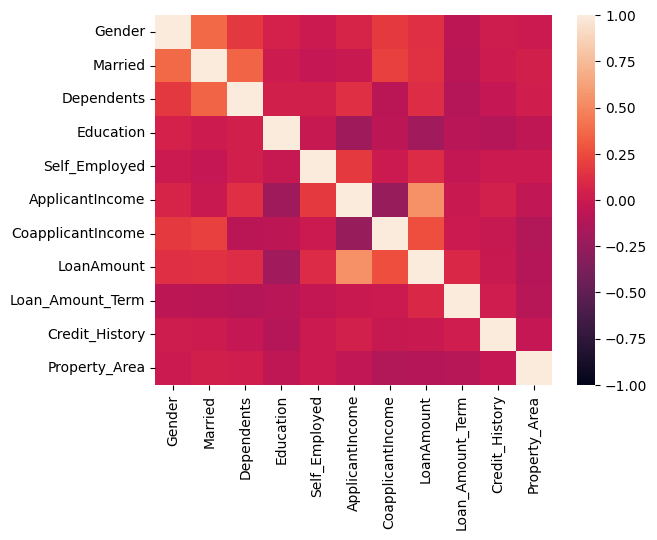

In [53]:
matrix = credit_df.corr()

sns.heatmap(matrix, annot=False, vmin=-1, vmax=1)

Remarques : très peu de corrélation en règle générale, légère corrélation entre ApplicantIncome et LoanAmmount

### Feature selection avec Boruta

In [54]:
from boruta import BorutaPy

In [58]:
feat_selector = BorutaPy(random_forest_best)

feat_selector.fit(X, y)

KeyboardInterrupt: 

In [ ]:
X_columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')

In [ ]:
feat_selector.support_

NameError: name 'feat_selector' is not defined

In [ ]:
feat_selector_columns = feat_selector.support_
interesting_columns = []
for i in range(len(feat_selector_columns)):
    if feat_selector_columns[i] == True:
        interesting_columns.append(X_columns[i])

print(interesting_columns)

NameError: name 'feat_selector' is not defined

In [ ]:
feat_selector.ranking_

NameError: name 'feat_selector' is not defined

In [ ]:
ranking = feat_selector.ranking_
five_best_columns = []
for i in range(1,6):
    for j in range(len(ranking)):
        if i == ranking[j]:
            five_best_columns.append(X_columns[j])
print(five_best_columns)

['LoanAmount', 'Credit_History', 'ApplicantIncome', 'CoapplicantIncome', 'Property_Area', 'Dependents']


In [ ]:
df.columns.difference(five_best_columns)

Index(['Education', 'Gender', 'Loan_Amount_Term', 'Loan_ID', 'Loan_Status',
       'Married', 'Self_Employed'],
      dtype='object')

### Créer un nouveau dataset avec seulement les 5 colonnes les plus intéressantes

In [ ]:
X = pd.DataFrame(data=X, columns=X_columns)
X = X.filter(five_best_columns)

print(X)


     LoanAmount  Credit_History  ApplicantIncome  CoapplicantIncome  \
0      0.184921        0.450801         0.898633          -0.852357   
1     -0.125588        0.450801         0.410559          -0.204048   
2     -1.328264        0.450801        -0.753846          -0.852357   
3     -0.300523        0.450801        -1.095498           0.876466   
4      0.158681        0.450801         0.933495          -0.852357   
..          ...             ...              ...                ...   
609   -1.262663        0.450801        -0.851461          -0.852357   
610   -1.743733        0.450801         0.194412          -0.852357   
611    1.645625        0.450801         1.282119          -0.819941   
612    0.989620        0.450801         1.219367          -0.852357   
613   -0.016254       -2.391002         0.410559          -0.852357   

     Property_Area  Dependents  
0         1.223298   -0.764389  
1        -1.318513    0.230386  
2         1.223298   -0.764389  
3         1.223

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Exercice 2 - Explicabilité

### Utilisation des SHap Values avec un random forest

In [ ]:
best_random_forest = RandomForestClassifier(criterion='entropy', max_depth=50, min_samples_leaf=4,min_samples_split=5, n_estimators=20)
best_random_forest.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=50, min_samples_leaf=4,
                       min_samples_split=5, n_estimators=20)

In [ ]:
import shap

C:\Users\admin\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
explainer = shap.Explainer(best_random_forest)
shap_values = explainer.shap_values(X_test)

Shap value renvoi une matrice 3D
Pour l'utiliser dans le summary plot on va choisir: shap_values['valeur_colonne', 'valeur_ligne', 'classe_recherché']

##### Summary plot

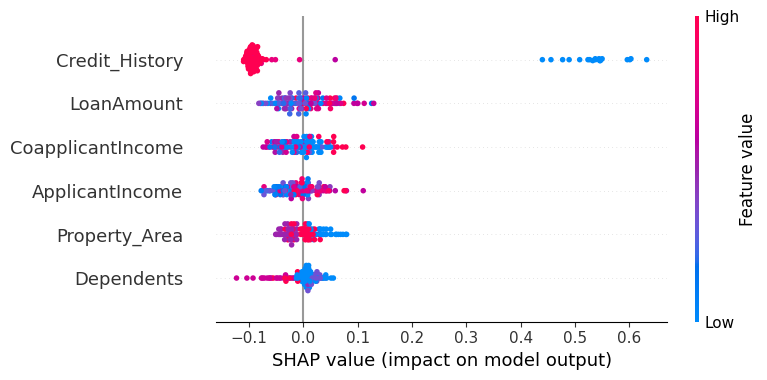

In [ ]:
shap.summary_plot(shap_values[:,:,0], X_test, feature_names=X.columns)

Summmary plot

Ici on choisit toutes les colonnes, toutes les lignes expliquant le fait d'avoir un crédit (0 = avoir crédit, 1 = ne pas avoir de crédit), pour voir l'impact des features sur le modèle

On peut voir que plus on a d'historique de crédit, plus ça va influencer négativement le résultat du modèle


Les autres features n'ont pas de réel impact sur le résultat du modèle

#### Bar plot

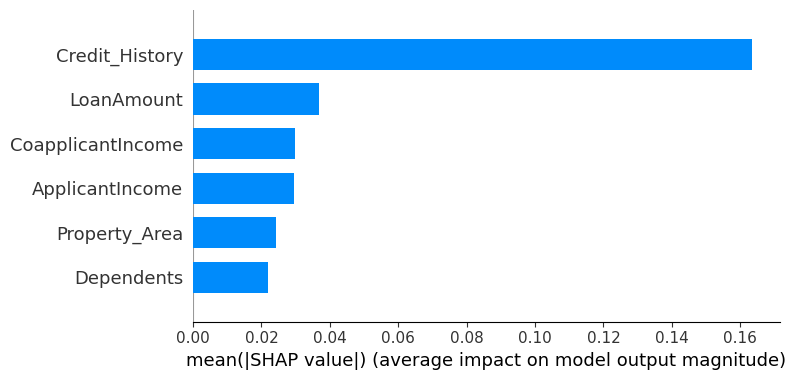

In [ ]:
shap.summary_plot(shap_values[:,:,0], X_test, feature_names=X.columns, plot_type='bar')

Ce graphe permet d'avoir l'impact de chaque feature sur le résultat du modèle

##### Waterfall plot

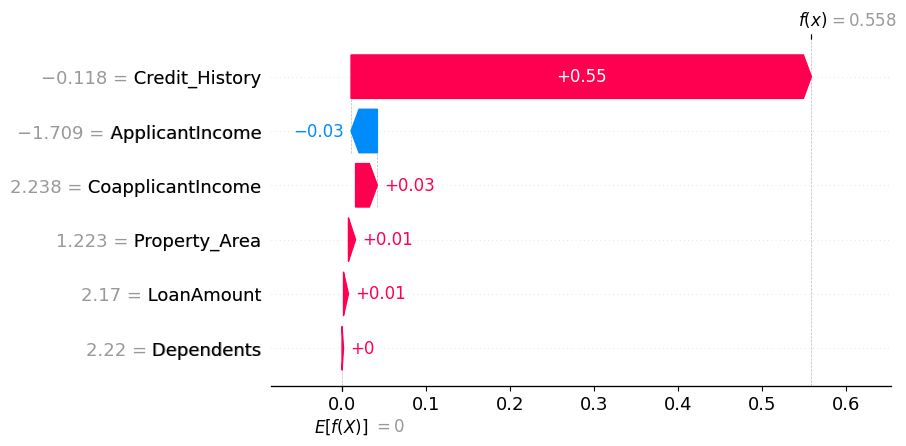

In [ ]:
instance_idx=20
shap.waterfall_plot(shap.Explanation(values=shap_values[instance_idx, :, 0],
                                    base_values=shap_values.mean(),
                                    data=X_train.iloc[instance_idx],
                                    feature_names=X_train.columns)              
                    )


Ce graphe permet de savoir comment chaque feature a impacté le résultat pour une instance donnée.

On peut voir ici que la feature "Credit_History" a eu un grand impact pour arriver au résultat (avoir un prêt). La seule feature qui a eu un impact négatif est "ApplicantIncome" mais son impact est quasiment nul.

## Cheminement de pensée à avoir

Il faut commencer par afficher le summary plot en bar pour connaitre quel est l'importance des features

Après on va afficher le summary plot classique pour savoir comment chaque feature à un impact

Puis on peut afficher le waterfall plot pour connaitre l'impact qu'a eu chaque feature sur le résultat donnée pour une instance (ici, pour une demande de crédit)

## Ice plots

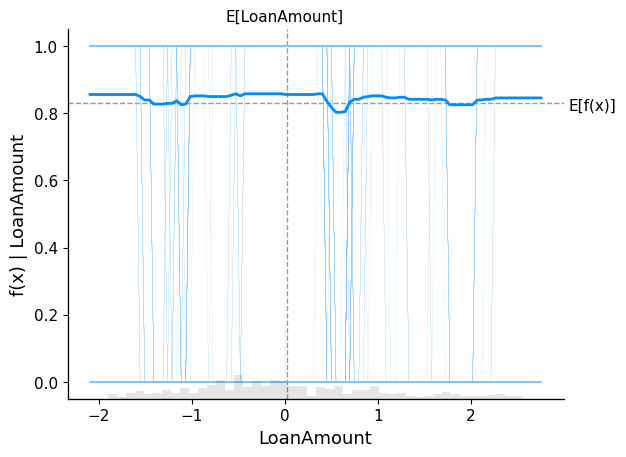

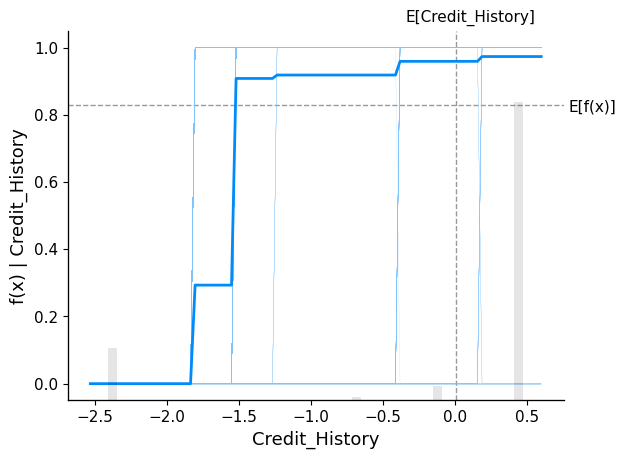

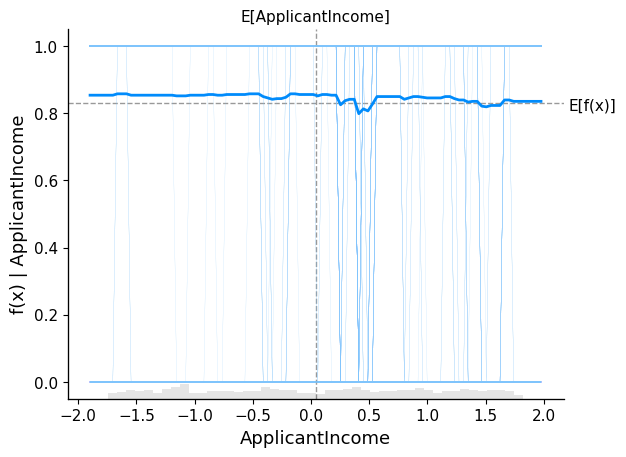

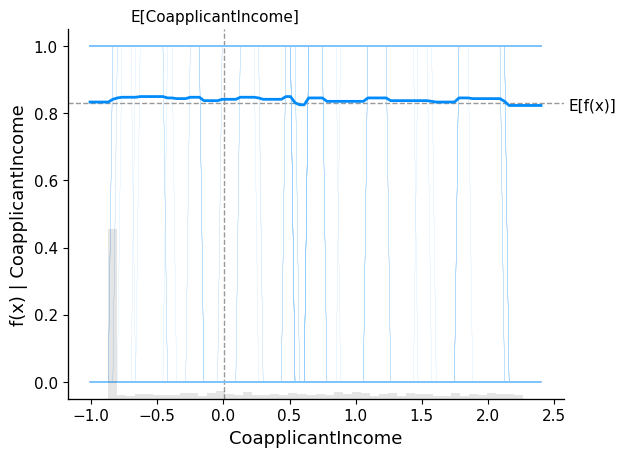

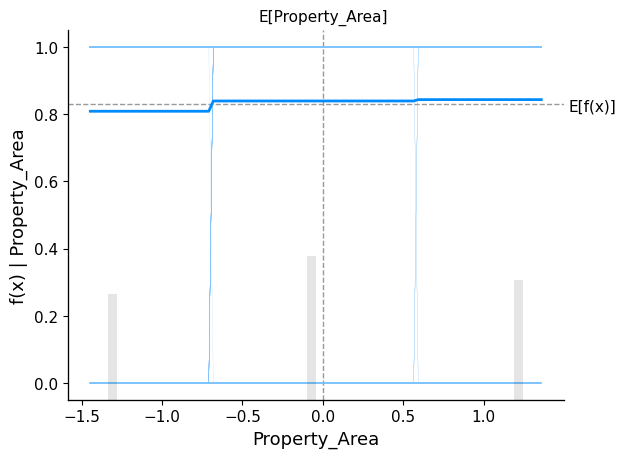

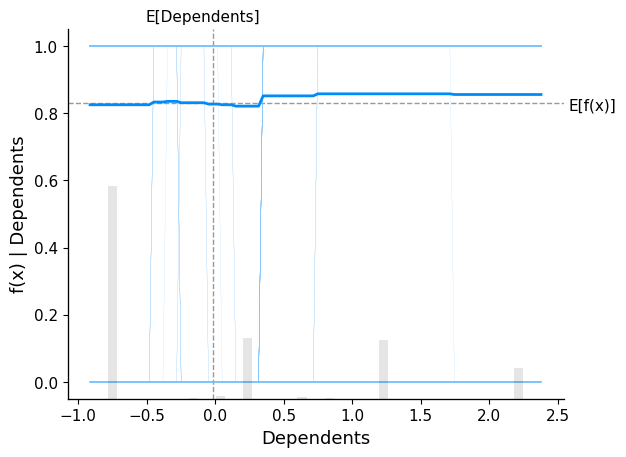

In [ ]:
for i in range(len(five_best_columns)):
    shap.plots.partial_dependence(
        ind=i,
        feature_names= five_best_columns,
        model=best_random_forest.predict,
        data=X_train,
        model_expected_value=True,
        feature_expected_value=True,
        ice=True,
    )

L'axe X représente la feature que nous observons et l'axe Y représente la prédiciton du modèle (dans notre cas avoir ou pas un prêt).

La courbe en gras est activé grace a "feature_expected_value=True", elle représente l'effet global de la variable sur les prédictions du modèle.

# Exercice 3 - Ajout des derniers algortihmes de ML

### Gradient Boosting Classifier - XGBoost

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
xgc = GradientBoostingClassifier()

In [ ]:
xgc.fit(X_train, y_train)

GradientBoostingClassifier()

In [ ]:
y_pred_train = xgc.predict(X_train)
y_pred_test = xgc.predict(X_test)
print(accuracy_score(y_train, y_pred_train))
print(accuracy_score(y_test, y_pred_test))

0.90020366598778
0.7723577235772358


In [ ]:
param_grid_xgboost = {
    "n_estimators" : [25, 50, 100, 200],
    "learning_rate" : [0.01, 0.1, 0.3],
    "max_depth" : [3, 4, 5, 6],
    "tol" : [0.0001, 0.001, 0.01, 1, 2, 3, 4, 5],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2, 4, 6],
    "max_features" : [None, "sqrt", "log2"]
}

In [ ]:
gscv_gradient = RandomizedSearchCV(GradientBoostingClassifier(), param_distributions=param_grid_xgboost, cv=5, n_iter=1000, n_jobs=-1)

In [ ]:
gscv_gradient.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=GradientBoostingClassifier(), n_iter=1000,
                   n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.1, 0.3],
                                        'max_depth': [3, 4, 5, 6],
                                        'max_features': [None, 'sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4, 6],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [25, 50, 100, 200],
                                        'tol': [0.0001, 0.001, 0.01, 1, 2, 3, 4,
                                                5]})

In [ ]:
best_xgc = gscv_gradient.best_estimator_
best_xgc

GradientBoostingClassifier(max_depth=4, max_features='log2', min_samples_leaf=2,
                           n_estimators=25, tol=2)

In [ ]:
print(best_xgc.score(X_train, y_train))
print(best_xgc.score(X_test, y_test))

0.8411405295315683
0.7804878048780488


### Neural Network

In [ ]:
from sklearn.neural_network import MLPClassifier

Neural network avec 2 couches cachées (la première avec 64 neuronnes et la deuxième avec 32 neuronnes) avec une fonction d'activation ReLU

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(64,32), activation='relu', max_iter=1000)
mlp.fit(X_train, y_train)

print(mlp.score(X_train, y_train))

# y_pred = mlp.predict(X_test)
# print(accuracy_score(y_test, y_pred))
print(mlp.score(X_test, y_test))

0.9531568228105907
0.7479674796747967


mlp.score(X_test, y_test) revient a faire y_pred = mlp.predict(X_test) puis print(accuracy_score(y_test, y_pred))


Neural network avec 3 couches cachées (la première avec 128 neuronnes, la deuxième avec 64 neuronnes et la troisième avec 32 neuronnes) avec une fonction d'activation ReLU

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(128,64,32), activation='relu', max_iter=1000)
mlp.fit(X_train, y_train)

print(mlp.score(X_train, y_train))

print(mlp.score(X_test, y_test))

0.9674134419551935
0.6747967479674797


# Fonctions générique pour trouver le meilleur algo de classification

### KNN

In [ ]:
def get_best_knn_classifier(X_train, y_train, X_test, y_test, param_grid_knn):
    result = {}
    result['knn'] = {}
    knn = KNeighborsClassifier()
    knn.fit(X_train, y_train)

    y_pred_train = knn.score(X_train, y_train)
    y_pred_test = knn.score(X_test, y_test)

    result['knn']['default'] = {'train': y_pred_train, 'test': y_pred_test}

    grid_search = GridSearchCV(estimator=knn, scoring='accuracy', param_grid=param_grid_knn, cv=5, n_jobs=-1)
    grid_search.fit(X_train, y_train)

    knn_best_params = grid_search.best_params_

    knn_best = grid_search.best_estimator_
    y_pred_train = knn_best.score(X_train, y_train)
    y_pred_test = knn_best.score(X_test, y_test)

    result['knn']['best'] = {'params':knn_best_params, 'train': y_pred_train, 'test': y_pred_test}
    return result

In [ ]:
param_grid_knn = {
    'n_neighbors': [3,5,7,9,11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}
knn_result = get_best_knn_classifier(X_train, y_train, X_test, y_test, param_grid_knn)

### SVM

In [ ]:
def get_best_svm_classifier(X_train, y_train, X_test, y_test, param_grid_svm):
    result = {}
    result['SVM'] = {}
    svm = SVC()
    svm.fit(X_train, y_train)

    y_pred_train = svm.score(X_train, y_train)
    y_pred_test = svm.score(X_test, y_test)

    result['SVM']['default'] = {'train': y_pred_train, 'test': y_pred_test}

    grid_search = GridSearchCV(estimator=svm, scoring='accuracy', param_grid=param_grid_svm, cv=5, n_jobs=-1)
    grid_search.fit(X_train, y_train)

    svm_best_params = grid_search.best_params_

    svm_best = grid_search.best_estimator_
    y_pred_train = svm_best.score(X_train, y_train)
    y_pred_test = svm_best.score(X_test, y_test)

    result['SVM']['best'] = {'params':svm_best_params, 'train': y_pred_train, 'test': y_pred_test}
    return result

In [ ]:
param_grid_svm = {
    'C': [00.1, 0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'degree': [2,3,4,5]
}

svm_result = get_best_svm_classifier(X_train, y_train, X_test, y_test, param_grid_svm)

### Decision tree

In [ ]:
def get_best_decision_tree_classifier(X_train, y_train, X_test, y_test, param_grid_decision_tree):
    result = {}
    result['DecisionTree'] = {}
    decision_tree = DecisionTreeClassifier()
    decision_tree.fit(X_train, y_train)

    y_pred_train = decision_tree.score(X_train, y_train)
    y_pred_test = decision_tree.score(X_test, y_test)

    result['DecisionTree']['default'] = {'train': y_pred_train, 'test': y_pred_test}

    grid_search = GridSearchCV(estimator=decision_tree, scoring='accuracy', param_grid=param_grid_decision_tree, cv=5, n_jobs=-1)
    grid_search.fit(X_train, y_train)

    decision_tree_best_params = grid_search.best_params_

    decision_tree_best = grid_search.best_estimator_
    y_pred_train = decision_tree_best.score(X_train, y_train)
    y_pred_test = decision_tree_best.score(X_test, y_test)

    result['DecisionTree']['best'] = {'params':decision_tree_best_params, 'train': y_pred_train, 'test': y_pred_test}

    return result

In [ ]:
param_grid_decision_tree = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2,5,10,20],
    'min_samples_leaf': [1,2,4,6],
    'max_features': [None, 'sqrt', 'log2']
}

decision_tree_result = get_best_decision_tree_classifier(X_train, y_train, X_test, y_test, param_grid_decision_tree)

### Random Forest

In [ ]:
def get_best_random_forest_classifier(X_train, y_train, X_test, y_test, param_grid_random_forest):
    result = {}
    result['RandomForest'] = {}
    random_forest = RandomForestClassifier()
    random_forest.fit(X_train, y_train)

    y_pred_train = random_forest.score(X_train, y_train)
    y_pred_test = random_forest.score(X_test, y_test)

    result['RandomForest']['default'] = {'train': y_pred_train, 'test': y_pred_test}

    randomized_search = RandomizedSearchCV(estimator=random_forest, scoring='accuracy', param_distributions=param_grid_random_forest, cv=5, n_jobs=-1, n_iter=500)
    randomized_search.fit(X_train, y_train)

    random_forest_best_params = randomized_search.best_params_

    random_forest_best = randomized_search.best_estimator_
    y_pred_train = random_forest_best.score(X_train, y_train)
    y_pred_test = random_forest_best.score(X_test, y_test)

    result['RandomForest']['best'] = {'params':random_forest_best_params, 'train': y_pred_train, 'test': y_pred_test}

    return result

In [ ]:
param_grid_random_forest = {
    'n_estimators': [20,100,200,300],
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2,5,10,20],
    'min_samples_leaf': [1,2,4,6],
    'max_features': [None, 'sqrt', 'log2'],
    'bootstrap': [True, False]
}

random_forest_result = get_best_random_forest_classifier(X_train, y_train, X_test, y_test, param_grid_random_forest)

### XGBoost

In [ ]:
def get_best_xgboost_classifier(X_train, y_train, X_test, y_test, param_grid_xgboost):
    result = {}
    result['XGBoost'] = {}
    xgboost = GradientBoostingClassifier()
    xgboost.fit(X_train, y_train)

    y_pred_train = xgboost.score(X_train, y_train)
    y_pred_test = xgboost.score(X_test, y_test)

    result['XGBoost']['default'] = {'train': y_pred_train, 'test': y_pred_test}

    randomized_search = RandomizedSearchCV(estimator=xgboost, scoring='accuracy', param_distributions=param_grid_xgboost, cv=5, n_jobs=-1, n_iter=500)
    randomized_search.fit(X_train, y_train)

    xgboost_best_params = randomized_search.best_params_

    xgboost_best = randomized_search.best_estimator_
    y_pred_train = xgboost_best.score(X_train, y_train)
    y_pred_test = xgboost_best.score(X_test, y_test)

    result['XGBoost']['best'] = {'params':xgboost_best_params, 'train': y_pred_train, 'test': y_pred_test}

    return result

In [ ]:
param_grid_xgboost = {
    "n_estimators" : [25, 50, 100, 200],
    "learning_rate" : [0.01, 0.1, 0.3],
    "max_depth" : [3, 4, 5, 6],
    "tol" : [0.0001, 0.001, 0.01, 1, 2, 3, 4, 5],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2, 4, 6],
    "max_features" : [None, "sqrt", "log2"]
}

xgboost_result = get_best_xgboost_classifier(X_train, y_train, X_test, y_test, param_grid_xgboost)

### Tableau

In [ ]:
all_result = [knn_result, svm_result, decision_tree_result, random_forest_result, xgboost_result]
print(all_result)

[{'knn': {'default': {'train': 0.8289205702647657, 'test': 0.7398373983739838}, 'best': {'params': {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}, 'train': 0.835030549898167, 'test': 0.7398373983739838}}}, {'SVM': {'default': {'train': 0.824847250509165, 'test': 0.7886178861788617}, 'best': {'params': {'C': 0.1, 'degree': 5, 'gamma': 'scale', 'kernel': 'poly'}, 'train': 0.8289205702647657, 'test': 0.7967479674796748}}}, {'DecisionTree': {'default': {'train': 1.0, 'test': 0.6504065040650406}, 'best': {'params': {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'min_samples_split': 2}, 'train': 0.8431771894093686, 'test': 0.7317073170731707}}}, {'RandomForest': {'default': {'train': 1.0, 'test': 0.7642276422764228}, 'best': {'params': {'n_estimators': 20, 'min_samples_split': 20, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 20, 'criterion': 'gini', 'bootstrap': True}, 'train': 0.8391038696537678, 'test': 0.7804878048780488

In [ ]:
def generate_markdown_table_from_list_for_classifiers(results_list):
    markdown_table = "| Algo | Hyperparams | Train score | Test score |\n"
    markdown_table += "|:----:|:-----------:|:-----:|:----:|\n"

    for result in results_list:
        for algo, result_dict in result.items():
            for key, values in result_dict.items():
                if key == 'default':
                    hyperparams = 'default'
                else:
                    hyperparams = values.get('params', '-')
                
                train_score = round(values['train'], 4)
                test_score = round(values['test'], 4)
                
                markdown_table += f"| {algo} | {hyperparams} | {train_score} | {test_score} |\n"
    
    return markdown_table

In [ ]:
markdown_table = generate_markdown_table_from_list_for_classifiers(all_result)
print(markdown_table)

| Algo | Hyperparams | Train score | Test score |
|:----:|:-----------:|:-----:|:----:|
| knn | default | 0.8289 | 0.7398 |
| knn | {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'} | 0.835 | 0.7398 |
| SVM | default | 0.8248 | 0.7886 |
| SVM | {'C': 0.1, 'degree': 5, 'gamma': 'scale', 'kernel': 'poly'} | 0.8289 | 0.7967 |
| DecisionTree | default | 1.0 | 0.6504 |
| DecisionTree | {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'min_samples_split': 2} | 0.8432 | 0.7317 |
| RandomForest | default | 1.0 | 0.7642 |
| RandomForest | {'n_estimators': 20, 'min_samples_split': 20, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 20, 'criterion': 'gini', 'bootstrap': True} | 0.8391 | 0.7805 |
| XGBoost | default | 0.9002 | 0.7805 |
| XGBoost | {'tol': 4, 'n_estimators': 25, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 4, 'learning_rate': 0.1} | 0.8493 | 0.7886 |



| Algo | Hyperparams | Train score | Test score |
|:----:|:-----------:|:-----:|:----:|
| knn | default | 0.8289 | 0.7398 |
| knn | {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'} | 0.835 | 0.7398 |
| SVM | default | 0.8248 | 0.7886 |
| SVM | {'C': 0.1, 'degree': 5, 'gamma': 'scale', 'kernel': 'poly'} | 0.8289 | 0.7967 |
| DecisionTree | default | 1.0 | 0.6504 |
| DecisionTree | {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'min_samples_split': 2} | 0.8432 | 0.7317 |
| RandomForest | default | 1.0 | 0.7642 |
| RandomForest | {'n_estimators': 20, 'min_samples_split': 20, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 20, 'criterion': 'gini', 'bootstrap': True} | 0.8391 | 0.7805 |
| XGBoost | default | 0.9002 | 0.7805 |
| XGBoost | {'tol': 4, 'n_estimators': 25, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 4, 'learning_rate': 0.1} | 0.8493 | 0.7886 |
